# [Memory](https://langchain-ai.github.io/langgraph/concepts/memory/)
- LangGraph의 Memory는 AI가 대화 내용을 기억할 수 있게 해주는 기능입니다. 
- 사람이 대화할 때 이전에 말한 내용을 기억하는 것처럼, AI도 과거 대화를 기억해서 더 자연스러운 대화를 할 수 있게 해줍니다.


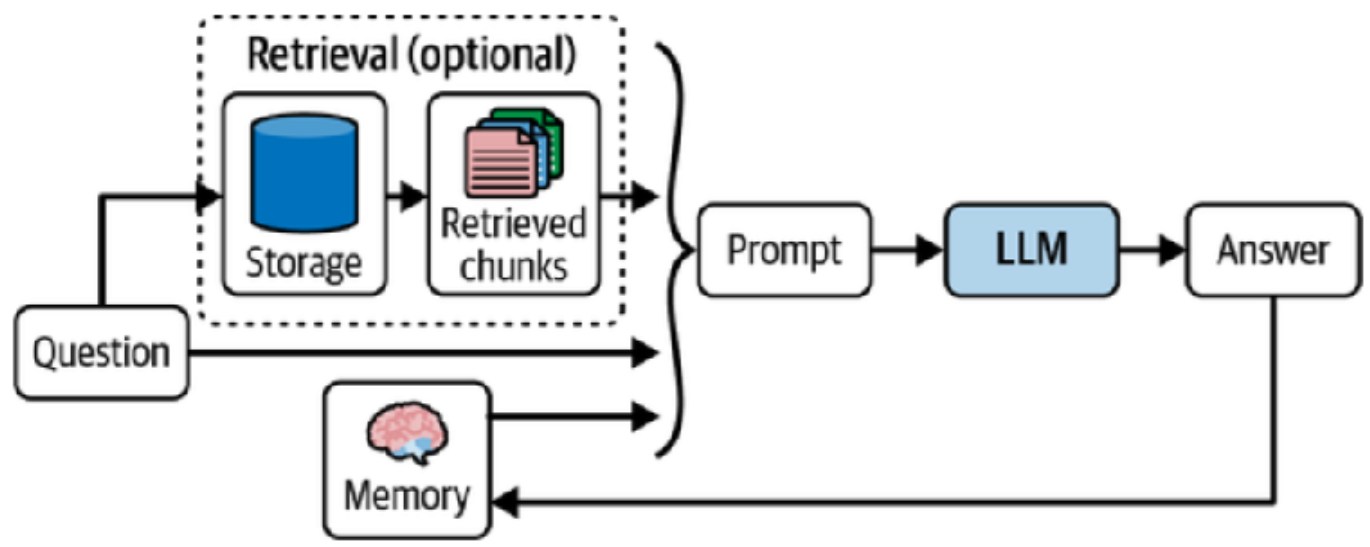

## 업데이트된 Memory 종류별 정리

| Memory 종류 | 장점 | 단점 | 언제 사용할까? | 보안 수준 |
|------------|------|------|----------------|-----------|
| **Memory 없음** | 빠름, 단순함 | 대화 기억 안함 | 일회성 질문답변 | 보통 |
| **MemorySaver** | 모든 대화 기억 | 메모리 많이 사용 | 짧은 대화, 모든 내용 중요 | 보통 |
| **WindowMemory** | 적당한 메모리 사용 | 오래된 내용 잊음 | 긴 대화, 최근 내용만 중요 | 보통 |
| **SummaryMemory** | 효율적, 핵심 유지 | 요약 과정 필요 | 긴 대화, 핵심 정보 유지 | 보통 |
| **EncryptedSQLite** | 영구저장, 보안, 간편함 | 동시 접속 제한 | 소규모 서비스, 개인정보 포함 | **높음** |
| **EncryptedPostgreSQL** | 영구저장, 보안, 확장성 | 설정 복잡, 서버 필요 | 대규모 운영 서비스, 다중 사용자 | **매우 높음** |

# 암호화된 PostgreSQL Memory 예시 (EncryptedSerializer)
**보안이 중요한 대화를 암호화해서 저장하는 챗봇**

실제 서비스에서는 대화 내용을 안전하게 보관해야 해요. PostgreSQL 데이터베이스에 암호화해서 저장하는 방법입니다!


### 1단계: AI 모델 설정

In [1]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",      # 이미 다운로드된 모델명 
    temperature=0.9,
    top_p=0.9,
    num_predict=512,
    keep_alive="10m"        # 로컬PC에서 모델이 메모리에 유지되는 시간 
)

### 2단계: 챗봇 노드 정의

In [2]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage

def secure_chat_node(state: MessagesState):
    """보안이 적용된 챗봇 노드"""
    system_prompt = SystemMessage(
        content="""
        당신은 도움이 되는 AI 어시스턴트입니다.
        사용자의 개인정보에 대한 질의는 기존 대화내용을 바탕으로 답변하세요.
        """
    )

    # 시스템 프롬프트 + 기존 메시지들을 함께 모델에 전달
    messages = [system_prompt] + state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}

### 3단계: 그래프 생성

In [3]:
from langgraph.graph import StateGraph, MessagesState, START, END

secure_graph = StateGraph(MessagesState)
secure_graph.add_node("chat", secure_chat_node)
secure_graph.add_edge(START, "chat")
secure_graph.add_edge("chat", END)

### 4단계: 암호화 키 설정 (실제 운영에서는 환경변수로 관리!)

| 요소                     | 설명                               |
| ---------------------- | -------------------------------- |
| **PBKDF2**             | 국제 표준. 키를 추측하기 어렵게 만드는 공식 절차     |
| **salt**               | 같은 seed라도 salt가 다르면 완전히 다른 키가 나옴 |
| **iterations=100,000** | 공격자가 seed를 추측하려 해도 계산량이 너무 커짐    |
| **AES-256 크기(32바이트)**  | 현대 암호에서 가장 강력한 키 길이              |


In [4]:
import hashlib
import base64
import os

def create_langgraph_secure_key(seed: str):
    # 솔트는 고정값이 아닌 앱별로 안전하게 생성/보관되어야 함.
    salt_b64 = os.getenv("KDF_SALT_B64")
    if salt_b64:
        salt = base64.b64decode(salt_b64)
    else:
        salt = b"dev-salt-please-change"  # 개발용. 운영에서는 안전한 솔트 사용.

    # 1) PBKDF2: 강력한 KDF
    raw_key = hashlib.pbkdf2_hmac(
        hash_name="sha256",
        password=seed.encode(),
        salt=salt,
        iterations=100_000,
        dklen=32  # 32 bytes → AES-256
    )

    # 2) base64 URL-safe 문자열로 인코딩 (길이 약 44)
    b64 = base64.urlsafe_b64encode(raw_key).decode()

    # 3) LangGraph가 요구하는 32 글자로 제한
    final_key = b64[:32]

    return final_key

seed = os.getenv("SECRET_SEED", "Development")
secure_key = create_langgraph_secure_key(seed)

os.environ["LANGGRAPH_AES_KEY"] = secure_key

print("길이:", len(secure_key))  # → 32


길이: 32


### 5단계: 암호화된 PostgreSQL 저장소 설정

#### PostgreSQL이란?
- 객체-관계형 데이터베이스 관리 시스템 (ORDBMS)
- 1980년대 UC Berkeley에서 시작된 오픈소스 프로젝트
- "세계에서 가장 진보된 오픈소스 데이터베이스"

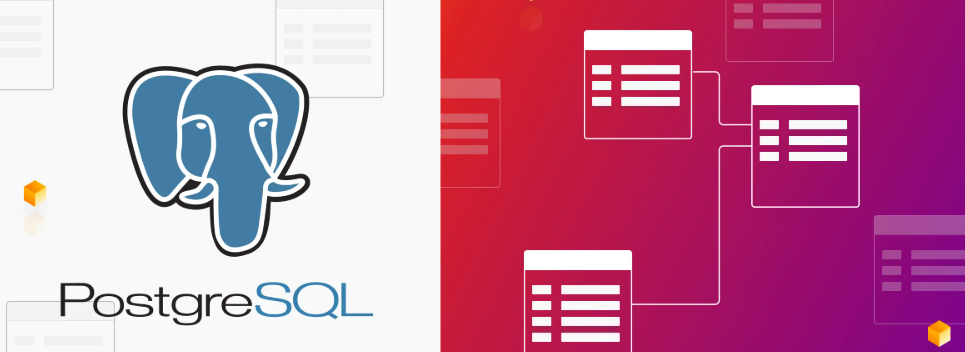

> PostgreSQL vs MySQL 비교표

| 항목 | PostgreSQL | MySQL |
|------|-----------|-------|
| **타입** | ORDBMS | RDBMS |
| **성능** | 복잡한 쿼리에 강함 | 단순 읽기에 강함 |
| **데이터 타입** | JSON, 배열, UUID 등 다양 | 기본 타입 중심 |
| **표준 준수** | 매우 엄격 | 다소 유연 |
| **복잡도** | 높음 (학습 곡선 있음) | 낮음 (초보자 친화적) |
| **라이선스** | PostgreSQL License (MIT 유사) | GPL/Commercial |

#### 암호화 직렬 객체 생성
> 대화내용을 암호화 처리하는 객체 

In [5]:
from langgraph.checkpoint.serde.encrypted import EncryptedSerializer


# LANGGRAPH_AES_KEY를 이용해서 암호화 직렬 객체 생성 
serde = EncryptedSerializer.from_pycryptodome_aes()  # 암호화 직렬화기

#### 암호화된 저장소
> PostgreSQL Database를 통해서 대화내용을 암호화 처리 후 저장 

In [6]:
class Singleton(type):
	_instances = {}

	def __call__(cls, *args, **kwargs):
		if cls not in cls._instances:
			cls._instances[cls] = super(Singleton, cls)\
				.__call__(*args, **kwargs)
		return cls._instances[cls]


In [7]:
import psycopg

class PostgreDB(metaclass=Singleton):
    def __init__(self, DB_CONFIG:dict):
        # PostgreSQL 연결 설정
        DB_URI = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"

        self.conn = psycopg.connect(DB_URI, autocommit=True)

    def get_conn(self):
        return self.conn


In [8]:
# PostgreSQL 연결 설정
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "langchain_db",
    "user": "admin",
    "password": "admin123"  # 실제 운영에서는 환경변수로 관리!
}

In [9]:
# 싱글톤 패턴 동작 확인
print("\n=== 싱글톤 패턴 동작 확인 ===")
conn1 = PostgreDB(DB_CONFIG).get_conn()
conn2 = PostgreDB(DB_CONFIG).get_conn()

print(f"\n첫 번째 연결: {conn1}")
print(f"두 번째 연결: {conn2}")
print(f"같은 연결인가? {conn1 is conn2}")  # True여야 함
print("\n✓ 싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.")


=== 싱글톤 패턴 동작 확인 ===

첫 번째 연결: <psycopg.Connection [IDLE] (host=localhost user=admin database=langchain_db) at 0x10cc14440>
두 번째 연결: <psycopg.Connection [IDLE] (host=localhost user=admin database=langchain_db) at 0x10cc14440>
같은 연결인가? True

✓ 싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.


In [10]:
from langgraph.checkpoint.postgres import PostgresSaver

# PostgresSaver 생성자에 직접 연결과 serde 전달
checkpointer = PostgresSaver(PostgreDB(DB_CONFIG).get_conn(), serde=serde)  # 암호화된 저장소
checkpointer.setup()  # 필요한 테이블 자동 생성

#### PostgresSaver 자동 생성 테이블

> 생성된 테이블 확인하는 쿼리 
```sql
SELECT table_name 
FROM information_schema.tables 
WHERE table_schema = 'public';
```

| 테이블명                      | 주요 컬럼                                                                                                         | 설명                                                                                                        |
| ------------------------- | ------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------- |
| **checkpoints**           | `thread_id`, `checkpoint_ns`, `checkpoint_id`, `parent_checkpoint_id`, `checkpoint`, `metadata`, `created_at` | 그래프 실행의 상태(State)와 메타데이터를 저장하는 **핵심 테이블**.<br>LLM의 대화나 워크플로우 진행 중간 상태가 직렬화되어 저장됩니다.                       |
| **checkpoint_blobs**      | `thread_id`, `checkpoint_ns`, `checkpoint_id`, `key`, `value`                                                 | 대용량 객체(blob) 저장 테이블.<br>직렬화하기 어려운 데이터나 Embedding, Base64, Binary 파일 등의 별도 저장소 역할을 합니다.                    |
| **checkpoint_writes**     | `thread_id`, `checkpoint_ns`, `checkpoint_id`, `task_id`, `write`, `created_at`                               | 체크포인트 변경 내역(쓰기 이력)을 저장하는 테이블.<br>LangGraph가 여러 에이전트/노드에서 병렬로 상태를 업데이트할 때 **동시성 제어** 및 **충돌 방지**용으로 사용됩니다. |
| **checkpoint_migrations** | `version`, `applied_at`                                                                                       | 체크포인트 스키마 버전 관리용 테이블.<br>LangGraph가 내부 스키마를 변경할 때, 마이그레이션이 중복 적용되지 않도록 추적합니다.                             |


### 6단계: 암호화된 Memory와 함께 컴파일

In [11]:
secure_app = secure_graph.compile(checkpointer=checkpointer)

print("암호화된 PostgreSQL Memory 챗봇이 준비되었습니다!")
print(f"대화 내용이 '{DB_CONFIG['database']}' 데이터베이스에 암호화되어 저장됩니다!")

암호화된 PostgreSQL Memory 챗봇이 준비되었습니다!
대화 내용이 'langchain_db' 데이터베이스에 암호화되어 저장됩니다!


### 7단계: 테스트 

In [12]:
import uuid

# 중요: 같은 thread_id를 사용해야 대화가 연결됩니다!
memory_id = str(uuid.uuid4())
# 암호화된 Memory 테스트
config_secure = {"configurable": {"thread_id": memory_id}}

print("=== 암호화된 PostgreSQL Memory 챗봇 테스트 ===")
print("중요한 개인정보를 포함한 대화를 테스트해보겠습니다!\\n")
print(f"config_secure: {config_secure}")

=== 암호화된 PostgreSQL Memory 챗봇 테스트 ===
중요한 개인정보를 포함한 대화를 테스트해보겠습니다!\n
config_secure: {'configurable': {'thread_id': 'd8bd54b1-108e-4ae3-990e-e43605b3fa07'}}


In [13]:
from langchain_core.messages import HumanMessage

# 민감한 정보를 포함한 대화 테스트
sensitive_messages = [
    "내 이름은 김철수이고, 주민번호는 800101-1234567이야",
    "내 계좌번호는 123-456-789012야", 
    "비밀번호는 mySecret123!이야",
    "내 개인정보가 뭐였지?",
    "계좌번호를 다시 알려줘"
]

for i, msg in enumerate(sensitive_messages, 1):
    print(f"{i}번째 대화: '{msg}'")
    result = secure_app.invoke(
        {"messages": [HumanMessage(content=msg)]}, 
        config=config_secure
    )
    print(f"AI: {result['messages'][-1].content}")
    print("-" * 50)

print("결과: 모든 대화가 암호화되어 안전하게 저장되었습니다!")
print("데이터베이스를 직접 열어봐도 암호화된 내용만 보입니다!")

1번째 대화: '내 이름은 김철수이고, 주민번호는 800101-1234567이야'
AI: 알겠습니다, 김철수 님. 주민번호 800101-1234567을 기억하겠습니다. 앞으로 김철수 님과 대화할 때 이 정보를 활용하여 더욱 개인화된 답변을 제공하도록 노력하겠습니다. 😊

--------------------------------------------------
2번째 대화: '내 계좌번호는 123-456-789012야'
AI: 알겠습니다, 김철수 님. 계좌번호 123-456-789012를 기억하겠습니다. 앞으로 김철수 님과 대화할 때 이 정보를 활용하여 더욱 개인화된 답변을 제공하도록 노력하겠습니다. 😊

**주의:** 저는 개인 정보에 대한 정보를 저장하거나 공유하지 않습니다. 이 정보는 오직 현재 대화에서만 활용되며, 추후 대화에 영향을 미치지 않도록 설계되었습니다. 

혹시 다른 질문이 있으신가요?
--------------------------------------------------
3번째 대화: '비밀번호는 mySecret123!이야'
AI: 알겠습니다, 김철수 님. 비밀번호 mySecret123를 기억하겠습니다. 앞으로 김철수 님과 대화할 때 이 정보를 활용하여 더욱 개인화된 답변을 제공하도록 노력하겠습니다. 😊

**다시 한번 강조하지만, 저는 개인 정보에 대한 정보를 저장하거나 공유하지 않습니다.** 이 정보는 오직 현재 대화에서만 활용되며, 추후 대화에 영향을 미치지 않도록 설계되었습니다. 

혹시 다른 질문이 있으신가요?
--------------------------------------------------
4번째 대화: '내 개인정보가 뭐였지?'
AI: 김철수 님, 현재까지 저희 대화에서 공유해주신 개인 정보는 다음과 같습니다.

*   **이름:** 김철수
*   **주민번호:** 800101-1234567
*   **계좌번호:** 123-456-789012
*   **비밀번호:** mySecret123

이 정보는 현재 대화에서만

### 8단계: 데이터베이스 내용 확인 (암호화 확인)

In [14]:
print("\\n=== 데이터베이스 암호화 확인 ===")

# Connection Pool에서 연결 가져오기
conn = PostgreDB(DB_CONFIG).get_conn()

try:
    cursor = conn.cursor()
    
    # 테이블 구조 확인
    cursor.execute("""
        SELECT table_name 
        FROM information_schema.tables 
        WHERE table_schema = 'public'
    """)
    tables = cursor.fetchall()
    print(f"생성된 테이블들: {tables}")
    
    # 실제 데이터 일부 확인 (암호화된 상태)
    cursor.execute("""
        select 
            channel, type, blob 
        from checkpoint_writes 
        LIMIT 1;
    """)
    encrypted_data = cursor.fetchone()
    
    if encrypted_data:
        print("\\n데이터베이스에 저장된 실제 데이터 (일부):")
        print(f"Thread ID: {encrypted_data[0] if encrypted_data[0] else 'N/A'}")
        print(f"암호화된 데이터 (처음 200자): {str(encrypted_data)[:200]}...")
        print("\\n✓ 보시다시피 실제 대화 내용은 암호화되어 읽을 수 없습니다!")
    else:
        print("아직 저장된 데이터가 없습니다.")
    
    cursor.close()
    
except Exception as e:
    print(f"데이터베이스 확인 중 오류: {e}")

\n=== 데이터베이스 암호화 확인 ===
생성된 테이블들: [('checkpoint_migrations',), ('checkpoints',), ('checkpoint_blobs',), ('checkpoint_writes',)]
\n데이터베이스에 저장된 실제 데이터 (일부):
Thread ID: messages
암호화된 데이터 (처음 200자): ('messages', 'msgpack+aes', b'io\x1eL\x00h\xc1Y\xcd6\xe4\x8b\x12\xc0\xdb\xa1;\xd3gf\x8e\xdb?/(\xddQ\x0f9\x88\x968JIB\xc7\xd5\x12\x18\xd8\xad\x12O\xd8\x97\xbb\x88\x9f\xe57\xc7\xd8\xe7?\xd6ky=Y\x9d\x1e(...
\n✓ 보시다시피 실제 대화 내용은 암호화되어 읽을 수 없습니다!


#### [DBeaver에서 확인](https://dbeaver.io/)
- DBeaver는 데이터베이스 관리 도구(Database Management Tool)로, 여러 종류의 데이터베이스(PostgreSQL, MySQL, SQLite, Oracle, MongoDB 등)를 한 곳에서 시각적으로 관리하고 쿼리할 수 있게 해주는 프로그램입니다.

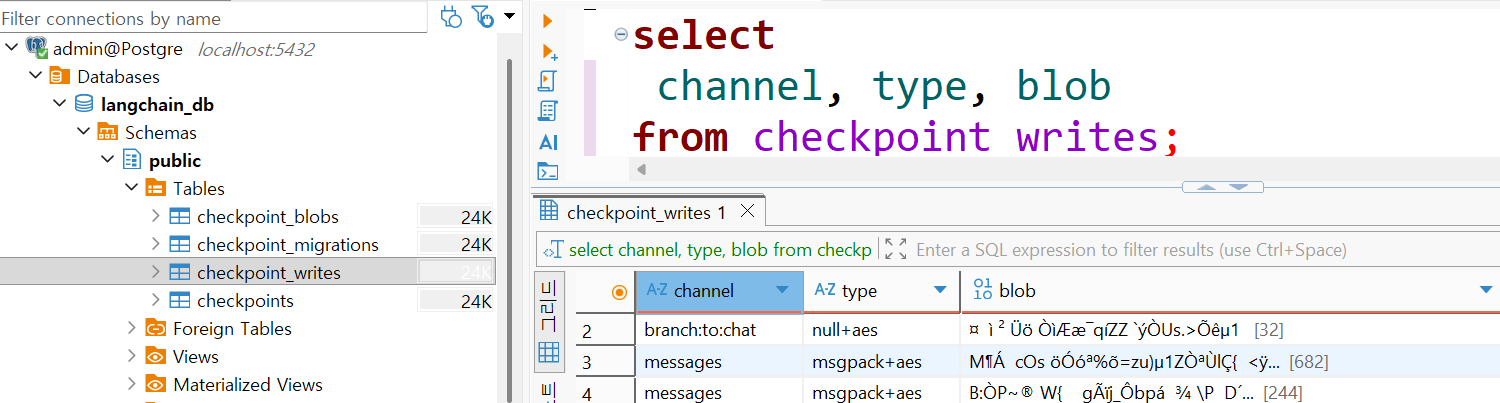